# Exploratory Data Analysis

The dataset has been preprocessed and merged from crash-level and vehicle-level data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("merged_data.csv")

df.head()

,crash_unit_id,crash_record_id,crash_date_x,unit_no,num_passengers,unit_type,vehicle_id,vehicle_year,vehicle_type,vehicle_category,...,prim_contributory_cause,num_units,most_severe_injury,injuries_total,injuries_fatal,injury_level,severe_crash,vehicle_age,passenger_group,vehicle_type_group
0,1000001,57945047eb951f4152fde013708fa029caf5d33fc2a2c2...,2020-11-25 17:46:00,1,NaN,DRIVER,947651.0,NaN,PICKUP,PASSENGER_VEHICLE,...,WEATHER,2.0,"REPORTED, NOT EVIDENT",1.0,0.0,REPORTED_NOT_EVIDENT,1,NaN,NaN,PICKUP
1,1000002,57945047eb951f4152fde013708fa029caf5d33fc2a2c2...,2020-11-25 17:46:00,2,1.0,DRIVER,947660.0,2020.0,PASSENGER,PASSENGER_VEHICLE,...,WEATHER,2.0,"REPORTED, NOT EVIDENT",1.0,0.0,REPORTED_NOT_EVIDENT,1,0.0,1-2,car
2,1000003,7cf1e0da7413f35c258ad67a3f0d08b10c9cf94a59bb4e...,2020-11-25 18:39:00,1,NaN,DRIVER,947657.0,2017.0,PASSENGER,PASSENGER_VEHICLE,...,UNKNOWN,3.0,NONINCAPACITATING INJURY,1.0,0.0,NON_INCAPACITATING,1,3.0,NaN,car
3,1000004,7cf1e0da7413f35c258ad67a3f0d08b10c9cf94a59bb4e...,2020-11-25 18:39:00,2,NaN,PARKED,947665.0,2020.0,PASSENGER,PASSENGER_VEHICLE,...,UNKNOWN,3.0,NONINCAPACITATING INJURY,1.0,0.0,NON_INCAPACITATING,1,0.0,NaN,car
4,1000005,7cf1e0da7413f35c258ad67a3f0d08b10c9cf94a59bb4e...,2020-11-25 18:39:00,3,NaN,DRIVER,947670.0,2017.0,SPORT UTILITY VEHICLE (SUV),PASSENGER_VEHICLE,...,UNKNOWN,3.0,NONINCAPACITATING INJURY,1.0,0.0,NON_INCAPACITATING,1,3.0,NaN,SPORT UTILITY VEHICLE (SUV)


## Dataset Overview

We first examine the basic structure of the dataset, including:
- Number of rows and columns
- Missing values
- Key variables used in analysis

In [3]:
print("Shape:", df.shape)
df.info()

df.isnull().sum().sort_values(ascending=False).head(15)

Shape: (382862, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382862 entries, 0 to 382861
Data columns (total 38 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   crash_unit_id            382862 non-null  int64  
 1   crash_record_id          382862 non-null  object 
 2   crash_date_x             382862 non-null  object 
 3   unit_no                  382862 non-null  int64  
 4   num_passengers           56502 non-null   float64
 5   unit_type                382859 non-null  object 
 6   vehicle_id               382862 non-null  float64
 7   vehicle_year             318551 non-null  float64
 8   vehicle_type             382862 non-null  object 
 9   vehicle_category         382862 non-null  object 
 10  vehicle_use              382862 non-null  object 
 11  travel_direction         352097 non-null  object 
 12  maneuver                 382862 non-null  object 
 13  occupant_cnt             382862 non-nul

passenger_group         326360
num_passengers          326360
vehicle_age              93942
vehicle_year             64311
crash_weekday            40809
crash_date_y             40809
posted_speed_limit       40809
roadway_surface_cond     40809
lighting_condition       40809
weather_condition        40809
is_weekend               40809
first_crash_type         40809
crash_hour               40809
crash_month              40809
crash_year               40809
dtype: int64

## Crash Severity Distribution

We analyze the distribution of crash severity using the `severe_crash` variable.

- 0 → Non-severe crash
- 1 → Severe crash

This helps us understand class imbalance and overall risk level.

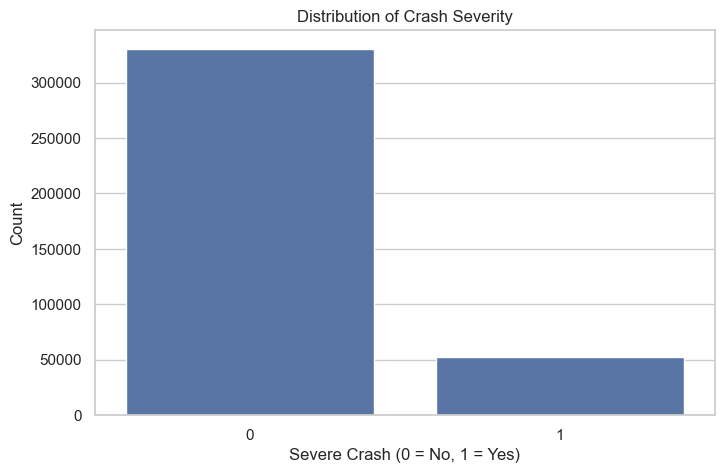

severe_crash
0    0.863549
1    0.136451
Name: proportion, dtype: float64

In [4]:
sns.countplot(data=df, x="severe_crash")
plt.title("Distribution of Crash Severity")
plt.xlabel("Severe Crash (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# proportion
df["severe_crash"].value_counts(normalize=True)

## Vehicle Type and Crash Severity

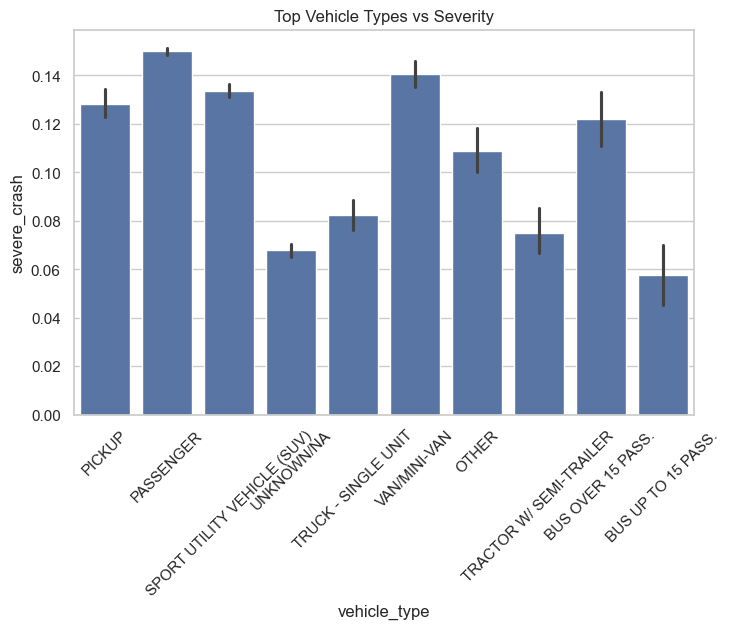

In [7]:
top_types = df["vehicle_type"].value_counts().nlargest(10).index
subset = df[df["vehicle_type"].isin(top_types)]

sns.barplot(data=subset, x="vehicle_type", y="severe_crash")
plt.xticks(rotation=45)
plt.title("Top Vehicle Types vs Severity")
plt.show()

## Crash Severity by Hour of Day

We examine how crash severity varies across different hours of the day.

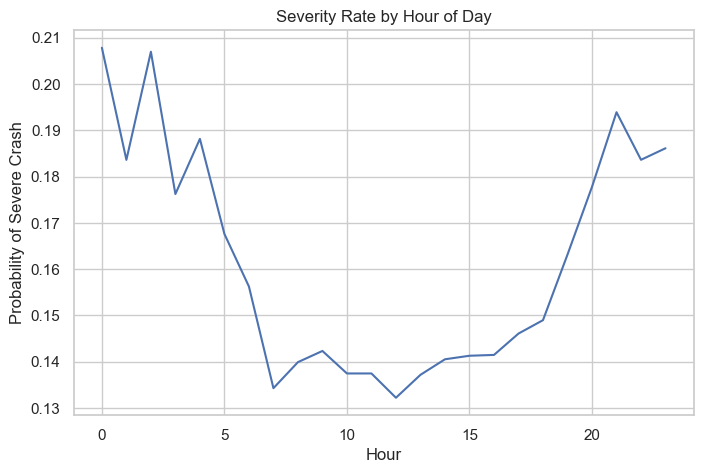

In [8]:
hourly = df.groupby("crash_hour")["severe_crash"].mean()

hourly.plot()
plt.title("Severity Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Probability of Severe Crash")
plt.show()

## Lighting Condition and Severity

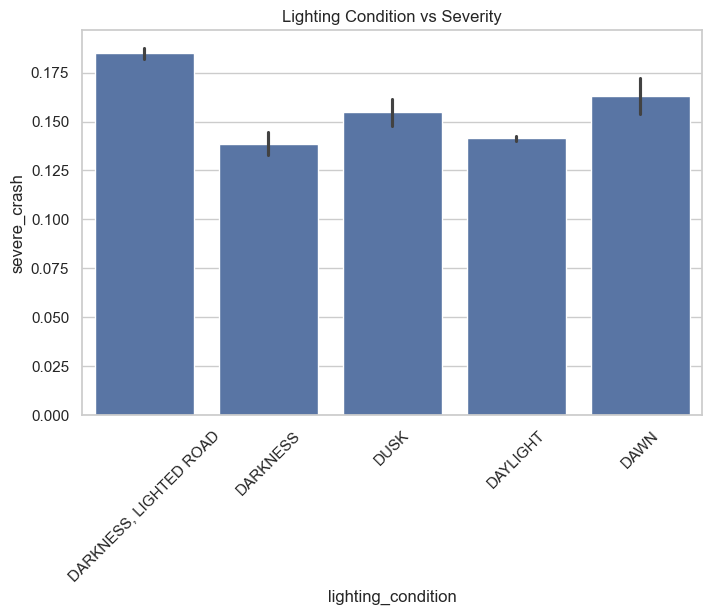

In [9]:
sns.barplot(data=df, x="lighting_condition", y="severe_crash")
plt.xticks(rotation=45)
plt.title("Lighting Condition vs Severity")
plt.show()

## Weather Condition and Severity

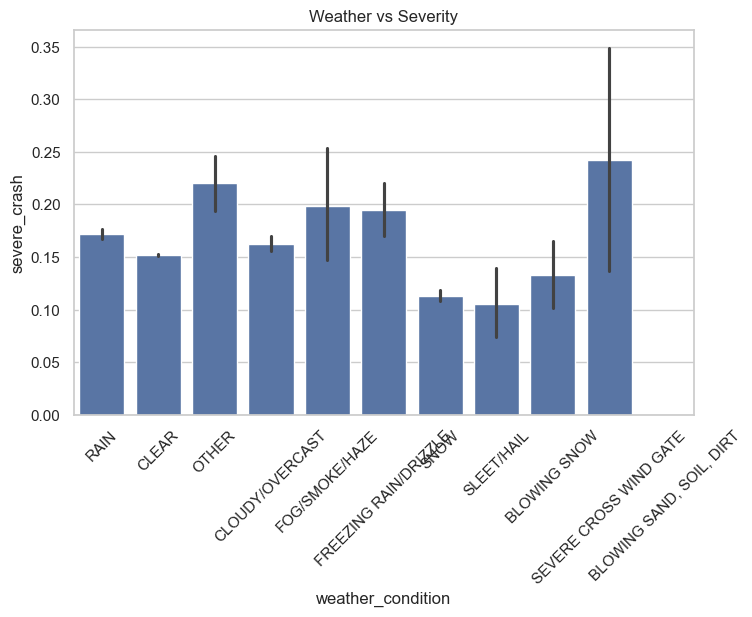

In [10]:
sns.barplot(data=df, x="weather_condition", y="severe_crash")
plt.xticks(rotation=45)
plt.title("Weather vs Severity")
plt.show()

## Road Surface Condition

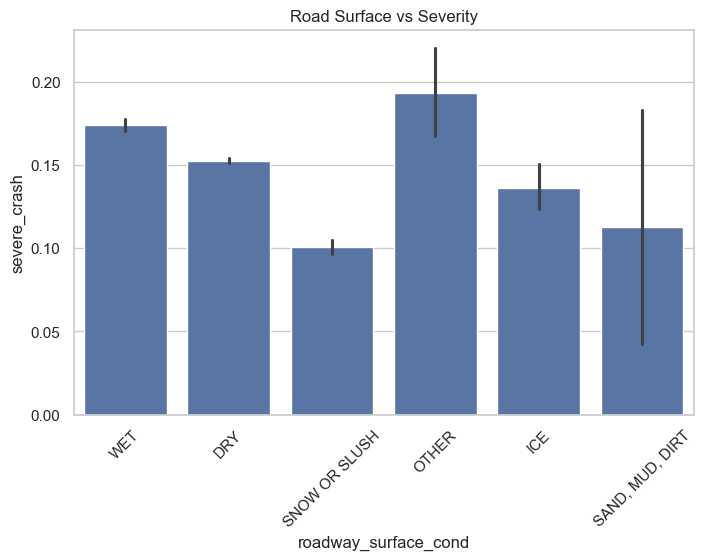

In [11]:
sns.barplot(data=df, x="roadway_surface_cond", y="severe_crash")
plt.xticks(rotation=45)
plt.title("Road Surface vs Severity")
plt.show()

## Primary Contributory Cause

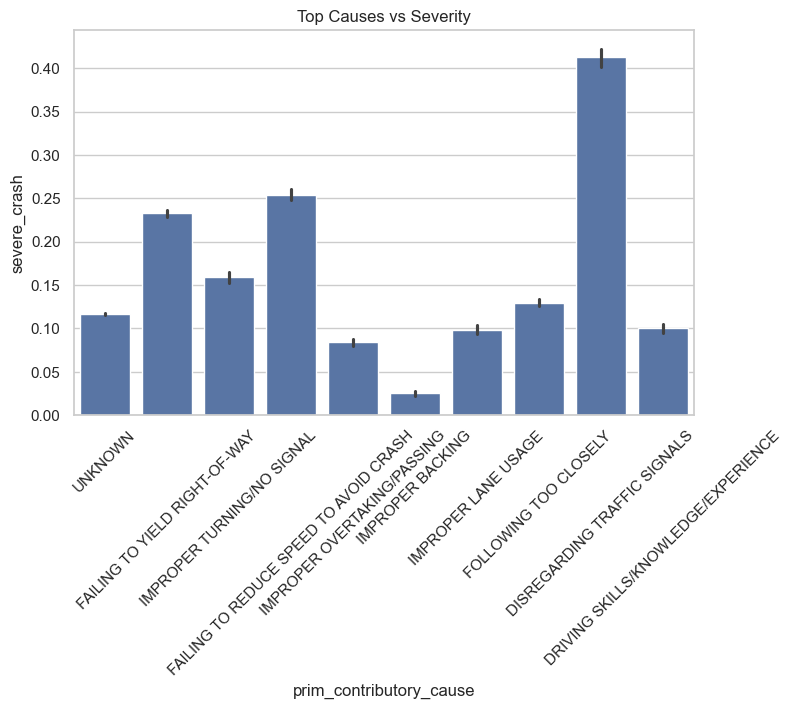

In [13]:
top_causes = df["prim_contributory_cause"].value_counts().nlargest(10).index
subset = df[df["prim_contributory_cause"].isin(top_causes)]

sns.barplot(data=subset, x="prim_contributory_cause", y="severe_crash")
plt.xticks(rotation=45)
plt.title("Top Causes vs Severity")
plt.show()

## Correlation Analysis

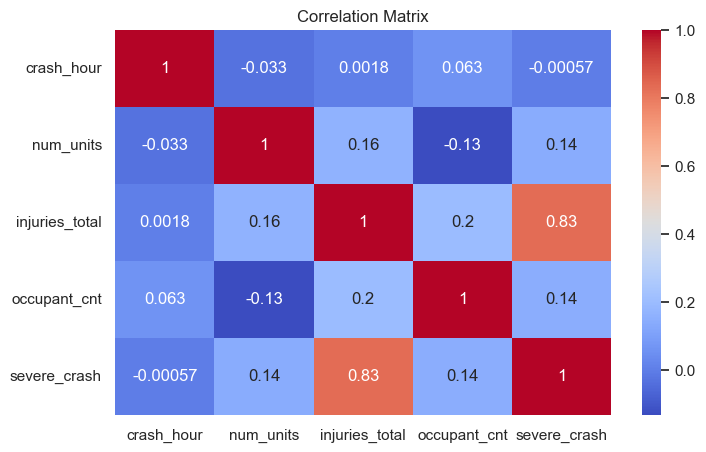

In [16]:
numeric_cols = [
    "crash_hour",
    "num_units",
    "injuries_total",
    "occupant_cnt",
    "severe_crash"
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Key Findings

From the exploratory data analysis, we found several patterns:

1. **Temporal Patterns**
   Crash severity shows a clear time-of-day pattern. Severity is highest during late night and early morning hours (approximately 0:00–4:00), decreases during daytime, and rises again in the evening. This suggests that low visibility and driver fatigue may contribute to more severe crashes.

2. **Vehicle Type Differences**
   Certain vehicle types, such as passenger vehicles and vans/minivans, exhibit higher severity rates compared to others. In contrast, smaller or less common vehicle categories tend to have lower severity rates. This indicates that vehicle characteristics and usage patterns may influence crash outcomes.

3. **Lighting Conditions**
   Crashes occurring in **darkness with lighting** show the highest severity levels, even higher than pure darkness. This may reflect high-speed urban environments where lighting exists but risk remains elevated.

4. **Weather Impact**
   Adverse weather conditions such as fog, snow, and strong winds are associated with higher crash severity. In contrast, clear weather conditions generally correspond to lower severity rates.

5. **Primary Contributory Causes**
   Human-related factors play a dominant role. Behaviors such as **following too closely**, **failing to yield**, and **improper turning** are strongly associated with higher severity crashes. This highlights the importance of driver behavior in determining crash outcomes.

6. **Correlation Insights**
   The correlation analysis shows a strong positive relationship between **total injuries and severe crashes**, which validates the definition of the target variable. Other variables (e.g., crash hour, number of units) have relatively weak direct correlations, suggesting that nonlinear models may be more effective.